In [ ]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms # for preprocessing
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # cpu will run for non gpu device
BATCH_SIZE = 256
EPOCHS = 5
SUBSET_SIZE = 10000    # for faster training
TEST_SIZE = 5000

print("Using device:", DEVICE)

Using device: cpu


In [ ]:
def get_dataloaders(normalize=True):
    transform = transforms.ToTensor() # converts image to tensor and scales:0-255 -> 0-1
    if normalize:
        transform = transforms.Compose([    #Combines multiple transformations
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))  # (((mean,),(std),)) tuple( ,) as mnist is grayscale
        ])

    train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    train_data = Subset(train_data, range(SUBSET_SIZE)) # range gives indices, till what in dataset
    test_data = Subset(test_data, range(TEST_SIZE))

    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=2) # numworker-> 2 worker processes load data in parallel (improves speed)
    return train_loader, test_loader

In [ ]:
class FFN(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()  #Initializes the parent class (nn.Module) so PyTorch can track parameters
        self.layers = nn.ModuleList() # list to store layers
        input_size = 28 * 28    # every image is flattened to 784 number (input feature size)

        for h in hidden_sizes:  #hidden layers
            self.layers.append(nn.Linear(input_size, h))
            input_size = h
        self.out = nn.Linear(input_size, 10) #output layer of 10 values

    def forward(self, x):
        x = x.view(x.size(0), -1) #flatten input ->[1,784]
        for layer in self.layers:
            x = torch.relu(layer(x)) # add relu(remove negative) to all layer
        return self.out(x)  # map classes- 0 or 1 or.. 9

In [ ]:
# 🔹 STEP 0: Input (1 image) — Original image: [1, 28, 28] → After flatten: [1, 784]
# 🔹 STEP 1: First hidden layer — Linear (784 → 3), x_new = W·x + b → output shape: [1, 3]
# 🔹 STEP 2: ReLU activation — negative values → 0 → [2.3, -1.5, 0.7] → [2.3, 0, 0.7]
# 🔹 STEP 3: Output layer (self.out) — Linear (3 → 10) → output shape: [1, 10]
# 🔹 STEP 4: Prediction — argmax over 10 scores → predicted digit (0–9)
# if fnn[[3,5]] means deeper model 784 to 3 to 5 to 10

In [ ]:
def get_optimizer(model, opt_type, lr):
    if opt_type == "sgd": # basic gradient descent, simple, slower convergence
        return optim.SGD(model.parameters(), lr=lr)
    elif opt_type == "momentum": # adds past gradient (velocity), faster + smoother than SGD
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_type == "adam": # adaptive learning rates + momentum, fastest convergence usually
        return optim.Adam(model.parameters(), lr=lr)

In [ ]:
def train_model(model, optimizer, loss_fn, train_loader, test_loader):
    model.to(DEVICE) # move model to device
    train_losses = []
    test_acc = []
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        model.train()
        batch_losses = []

        for X, y in train_loader: # training mode
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad() #  clear old grad
            yhat = model(X) #Forward pass — predictions [batch, 10]
            loss = loss_fn(yhat, y)
            loss.backward() # compute gradients
            optimizer.step() # adjust weights
            batch_losses.append(loss.item())

        avg_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(avg_loss)
        model.eval() # Eval mode — disable training behavior
        correct = 0
        total = 0

        with torch.no_grad(): # No grad — no learning, only inference -> predictions
            for X, y in test_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                preds = torch.argmax(model(X), dim=1)  # gives classified scores ->[2,3,0,2..]
                correct += (preds == y).sum().item()   # correctly ->sum of true (y and pred matched)
                total += y.size(0)  # total size of y

        acc = correct / total
        test_acc.append(acc)
        print(f"Loss: {avg_loss:.4f} | Accuracy: {acc:.4f}")

    return train_losses, test_acc

## EXPERIMENTS

In [ ]:
train_loader, test_loader = get_dataloaders()
loss_fn = nn.CrossEntropyLoss()
results_opt = {} # for plot comparision {sgd , adam , momentum :  (losscurve,accuracy)}

for opt in ["sgd", "momentum", "adam"]:
    print(f"\nRunning optimizer: {opt}")
    model = FFN([128])
    optimizer = get_optimizer(model, opt, lr=0.01)
    losses, acc = train_model(model, optimizer, loss_fn, train_loader, test_loader)
    results_opt[opt] = (losses, acc)


Running optimizer: sgd
Epoch 1/5
Loss: 2.1422 | Accuracy: 0.4026
Epoch 2/5
Loss: 1.8188 | Accuracy: 0.5556
Epoch 3/5
Loss: 1.4967 | Accuracy: 0.6760
Epoch 4/5
Loss: 1.2220 | Accuracy: 0.7262
Epoch 5/5
Loss: 1.0111 | Accuracy: 0.7452

Running optimizer: momentum
Epoch 1/5
Loss: 1.4680 | Accuracy: 0.7508
Epoch 2/5
Loss: 0.5166 | Accuracy: 0.8364
Epoch 3/5
Loss: 0.4053 | Accuracy: 0.8508
Epoch 4/5
Loss: 0.3531 | Accuracy: 0.8608
Epoch 5/5
Loss: 0.3266 | Accuracy: 0.8720

Running optimizer: adam
Epoch 1/5
Loss: 1.1021 | Accuracy: 0.8260
Epoch 2/5
Loss: 0.3759 | Accuracy: 0.8572
Epoch 3/5
Loss: 0.2911 | Accuracy: 0.8606
Epoch 4/5
Loss: 0.2694 | Accuracy: 0.8888
Epoch 5/5
Loss: 0.2169 | Accuracy: 0.8992


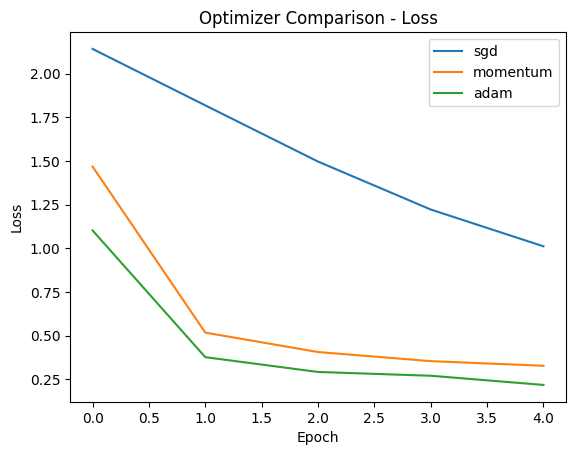

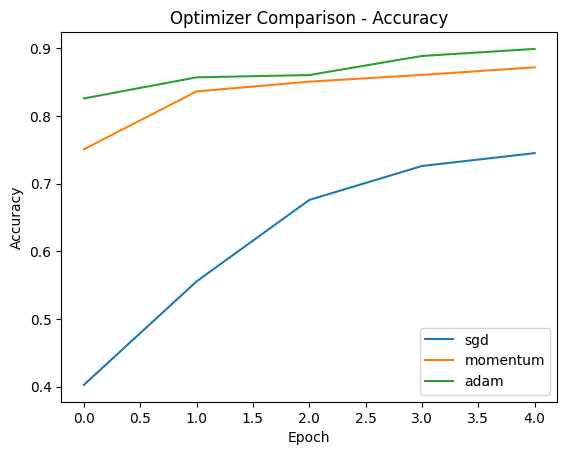

In [ ]:
# Loss
for opt, (losses, acc) in results_opt.items():
    plt.plot(losses, label=opt)
plt.title("Optimizer Comparison - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy
for opt, (losses, acc) in results_opt.items():
    plt.plot(acc, label=opt)

plt.title("Optimizer Comparison - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
configs = {     # experiments on different architectures - deeper wider etc
    "small": [64],
    "medium": [128],
    "large": [256, 128]
}

results_cap = {} # result dict for plot
for name, config in configs.items():
    print(f"\nRunning model: {name}")
    model = FFN(config)
    optimizer = get_optimizer(model, "adam", lr=0.001)
    losses, acc = train_model(model, optimizer, loss_fn, train_loader, test_loader)
    results_cap[name] = (losses, acc)


Running model: small
Epoch 1/5
Loss: 1.3469 | Accuracy: 0.7652
Epoch 2/5
Loss: 0.5817 | Accuracy: 0.8380
Epoch 3/5
Loss: 0.4368 | Accuracy: 0.8520
Epoch 4/5
Loss: 0.3831 | Accuracy: 0.8658
Epoch 5/5
Loss: 0.3421 | Accuracy: 0.8732

Running model: medium
Epoch 1/5
Loss: 1.1940 | Accuracy: 0.8106
Epoch 2/5
Loss: 0.4945 | Accuracy: 0.8474
Epoch 3/5
Loss: 0.3833 | Accuracy: 0.8660
Epoch 4/5
Loss: 0.3511 | Accuracy: 0.8766
Epoch 5/5
Loss: 0.3240 | Accuracy: 0.8762

Running model: large
Epoch 1/5
Loss: 1.1446 | Accuracy: 0.8004
Epoch 2/5
Loss: 0.4232 | Accuracy: 0.8630
Epoch 3/5
Loss: 0.3365 | Accuracy: 0.8792
Epoch 4/5
Loss: 0.2917 | Accuracy: 0.8860
Epoch 5/5
Loss: 0.2717 | Accuracy: 0.8888


In [ ]:
results_lr = {}
for lr in [0.1, 0.01, 0.001]: # expt of different lr
    print(f"\nRunning LR: {lr}")
    model = FFN([128])
    optimizer = get_optimizer(model, "adam", lr=lr)
    losses, acc = train_model(model, optimizer, loss_fn, train_loader, test_loader)
    results_lr[f"lr={lr}"] = (losses, acc)


Running LR: 0.1
Epoch 1/5
Loss: 35.0648 | Accuracy: 0.2328
Epoch 2/5
Loss: 1.7902 | Accuracy: 0.3038
Epoch 3/5
Loss: 1.7456 | Accuracy: 0.3024
Epoch 4/5
Loss: 1.6777 | Accuracy: 0.3170
Epoch 5/5
Loss: 1.6751 | Accuracy: 0.3296

Running LR: 0.01
Epoch 1/5
Loss: 1.4171 | Accuracy: 0.7994
Epoch 2/5
Loss: 0.3986 | Accuracy: 0.8102
Epoch 3/5
Loss: 0.3356 | Accuracy: 0.8760
Epoch 4/5
Loss: 0.2475 | Accuracy: 0.8920
Epoch 5/5
Loss: 0.2212 | Accuracy: 0.8668

Running LR: 0.001
Epoch 1/5
Loss: 1.1629 | Accuracy: 0.7894
Epoch 2/5
Loss: 0.4795 | Accuracy: 0.8430
Epoch 3/5
Loss: 0.3733 | Accuracy: 0.8632
Epoch 4/5
Loss: 0.3289 | Accuracy: 0.8758
Epoch 5/5
Loss: 0.3012 | Accuracy: 0.8800


In [ ]:
results_norm = {}  # expt on normalization
for norm in [True, False]: # Runs training twice: once with normalization, once without
    print(f"\nNormalization: {norm}")
    train_loader, test_loader = get_dataloaders(normalize=norm)
    model = FFN([128])
    optimizer = get_optimizer(model, "adam", lr=0.001)
    losses, acc = train_model(model, optimizer, loss_fn, train_loader, test_loader)
    results_norm[f"normalize={norm}"] = (losses, acc)


Normalization: True
Epoch 1/5
Loss: 1.1806 | Accuracy: 0.8122
Epoch 2/5
Loss: 0.4890 | Accuracy: 0.8446
Epoch 3/5
Loss: 0.3844 | Accuracy: 0.8676
Epoch 4/5
Loss: 0.3469 | Accuracy: 0.8460
Epoch 5/5
Loss: 0.3311 | Accuracy: 0.8756

Normalization: False
Epoch 1/5
Loss: 1.3180 | Accuracy: 0.8212
Epoch 2/5
Loss: 0.4732 | Accuracy: 0.8680
Epoch 3/5
Loss: 0.3508 | Accuracy: 0.8794
Epoch 4/5
Loss: 0.3126 | Accuracy: 0.8868
Epoch 5/5
Loss: 0.2778 | Accuracy: 0.8930


In [ ]:
results_reg = {} # experiment on regularization L2(1e-4 or 0.0001)
for wd in [0, 1e-4]:
    print(f"\nWeight decay: {wd}")
    model = FFN([128])
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    losses, acc = train_model(model, optimizer, loss_fn, train_loader, test_loader)
    results_reg[f"L2={wd}"] = (losses, acc)


Weight decay: 0
Epoch 1/5
Loss: 1.2739 | Accuracy: 0.8090
Epoch 2/5
Loss: 0.4782 | Accuracy: 0.8628
Epoch 3/5
Loss: 0.3493 | Accuracy: 0.8824
Epoch 4/5
Loss: 0.3074 | Accuracy: 0.8880
Epoch 5/5
Loss: 0.2726 | Accuracy: 0.8956

Weight decay: 0.0001
Epoch 1/5
Loss: 1.2855 | Accuracy: 0.8034
Epoch 2/5
Loss: 0.4831 | Accuracy: 0.8630
Epoch 3/5
Loss: 0.3649 | Accuracy: 0.8748
Epoch 4/5
Loss: 0.3100 | Accuracy: 0.8790
Epoch 5/5
Loss: 0.2848 | Accuracy: 0.8906


In [ ]:
def plot_experiment(results, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss subplot
    for name, (losses, acc) in results.items():
        axes[0].plot(losses, label=name)

    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy subplot
    for name, (losses, acc) in results.items():
        axes[1].plot(acc, label=name)

    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

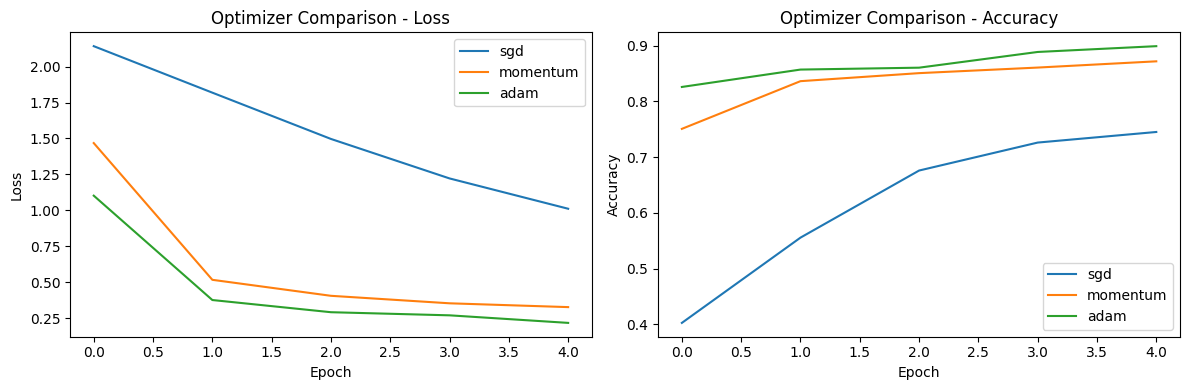

In [ ]:
plot_experiment(results_opt, "Optimizer Comparison")

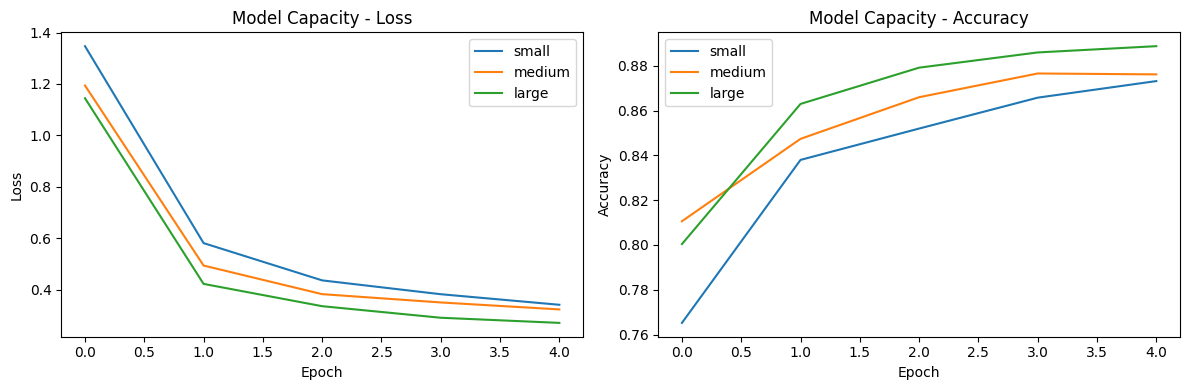

In [ ]:
plot_experiment(results_cap, "Model Capacity")

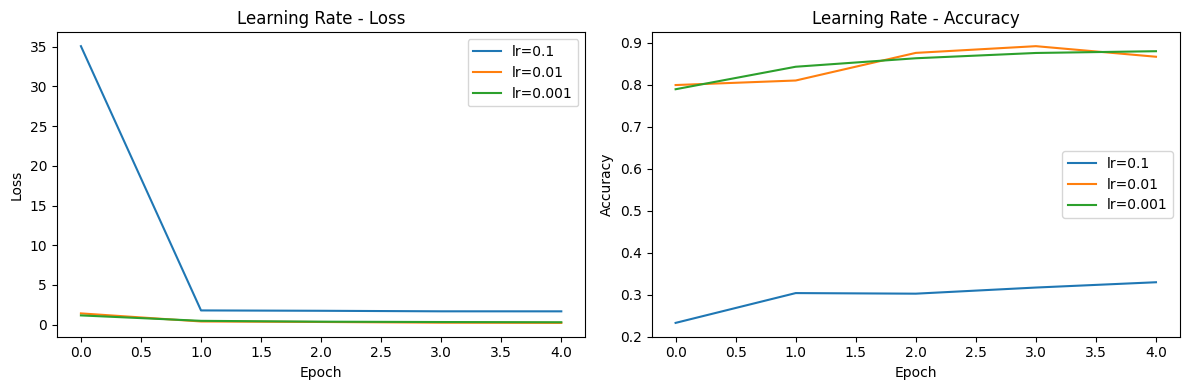

In [ ]:
plot_experiment(results_lr, "Learning Rate")

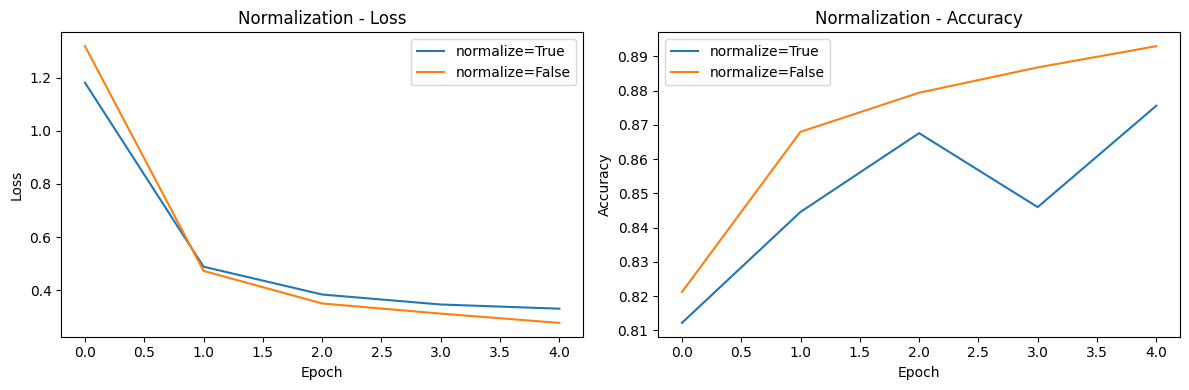

In [ ]:
plot_experiment(results_norm, "Normalization")

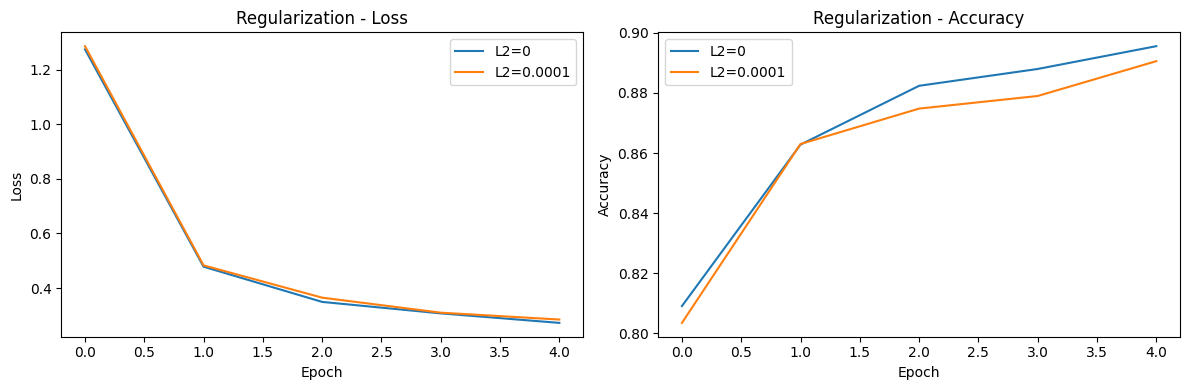

In [ ]:
plot_experiment(results_reg, "Regularization")